In [1]:
# 0) Imports & environment
import os
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# matplotlib inline for Colab
%matplotlib inline


In [2]:
# 1) Config
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BATCH_SIZE = 128
TEST_BATCH = 256
EPOCHS = 5           # increase if you want better clean accuracy (10+)
LEARNING_RATE = 1e-3

# choose three epsilons between 0.05 and 0.30
EPS_LIST = [0.05, 0.15, 0.25]

PGD_STEPS = 40
PGD_ALPHA = 0.01

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Device: cuda


In [3]:
# 2) Data (MNIST)
transform = transforms.Compose([transforms.ToTensor()])  # [0,1]
train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=TEST_BATCH, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 457kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.68MB/s]


In [4]:
# 3) Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.fc1   = nn.Linear(64*14*14, 128)
        self.fc2   = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(self.dropout(x)))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(DEVICE)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=12544, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [5]:
# 4) Training utilities
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = out.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            preds = out.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total += x.size(0)
    return total_loss/total, total_correct/total


In [6]:
# 5) Train
print("Starting training for {} epochs...".format(EPOCHS))
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    te_loss, te_acc = eval_model(model, test_loader, criterion, DEVICE)
    print(f"Epoch {epoch}/{EPOCHS}: Train Loss={tr_loss:.4f}, Train Acc={tr_acc:.4f} | Test Loss={te_loss:.4f}, Test Acc={te_acc:.4f}")

# Save model
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "mnist_cnn.pth"))

# Record clean metrics
clean_train_loss, clean_train_acc = eval_model(model, train_loader, criterion, DEVICE)
clean_test_loss, clean_test_acc = eval_model(model, test_loader, criterion, DEVICE)
print(f"CLEAN: Train Acc: {clean_train_acc:.6f}  | Test Acc: {clean_test_acc:.6f}")


Starting training for 5 epochs...
Epoch 1/5: Train Loss=0.2076, Train Acc=0.9375 | Test Loss=0.0517, Test Acc=0.9832
Epoch 2/5: Train Loss=0.0549, Train Acc=0.9828 | Test Loss=0.0371, Test Acc=0.9874
Epoch 3/5: Train Loss=0.0369, Train Acc=0.9883 | Test Loss=0.0356, Test Acc=0.9874
Epoch 4/5: Train Loss=0.0270, Train Acc=0.9911 | Test Loss=0.0444, Test Acc=0.9849
Epoch 5/5: Train Loss=0.0220, Train Acc=0.9925 | Test Loss=0.0325, Test Acc=0.9898
CLEAN: Train Acc: 0.997200  | Test Acc: 0.989800


In [7]:
# 6) Attack implementations (FGSM & PGD)
def fgsm_attack(model, x, y, eps, targeted=False, target_label=None):
    x_adv = x.clone().detach().to(DEVICE)
    x_adv.requires_grad = True
    model.zero_grad()
    outputs = model(x_adv)
    if targeted:
        assert target_label is not None
        loss = criterion(outputs, target_label.to(DEVICE))
        loss.backward()
        grad = x_adv.grad.data
        perturbed = x_adv - eps * grad.sign()
    else:
        loss = criterion(outputs, y.to(DEVICE))
        loss.backward()
        grad = x_adv.grad.data
        perturbed = x_adv + eps * grad.sign()
    perturbed = torch.clamp(perturbed, 0.0, 1.0).detach()
    return perturbed

def pgd_attack(model, x, y, eps, alpha=PGD_ALPHA, iters=PGD_STEPS, targeted=False, target_label=None):
    model.eval()
    x_orig = x.clone().detach().to(DEVICE)
    perturbed = x_orig.clone().detach()
    # random start
    perturbed = perturbed + torch.empty_like(perturbed).uniform_(-eps, eps)
    perturbed = torch.clamp(perturbed, 0.0, 1.0)
    for _ in range(iters):
        perturbed.requires_grad = True
        outputs = model(perturbed)
        model.zero_grad()
        if targeted:
            assert target_label is not None
            loss = criterion(outputs, target_label.to(DEVICE))
            loss.backward()
            grad = perturbed.grad.data
            perturbed = perturbed - alpha * grad.sign()
        else:
            loss = criterion(outputs, y.to(DEVICE))
            loss.backward()
            grad = perturbed.grad.data
            perturbed = perturbed + alpha * grad.sign()
        # project
        perturbed = torch.max(torch.min(perturbed, x_orig + eps), x_orig - eps)
        perturbed = torch.clamp(perturbed, 0.0, 1.0).detach()
    return perturbed

# Wrappers for batch API
def fgsm_batch(model, x, y, eps, targeted=False, target_label=None):
    return fgsm_attack(model, x, y, eps, targeted=targeted, target_label=target_label)

def pgd_batch(model, x, y, eps, targeted=False, target_label=None):
    return pgd_attack(model, x, y, eps, alpha=PGD_ALPHA, iters=PGD_STEPS, targeted=targeted, target_label=target_label)


In [8]:
# 7) Evaluation helper (generate adversarial examples outside no_grad; evaluate under no_grad)
def evaluate_attack_on_loader(model, loader, attack_fn, eps, targeted=False, target_fn=None, device=DEVICE, verbose=True):
    """
    Returns:
      acc_orig: accuracy on the original true label after attack (lower means stronger attack)
      acc_target: for targeted attacks, fraction predicted as target (None if not targeted)
    """
    model.eval()
    total = 0
    correct_orig = 0
    correct_target = 0

    it = loader
    if verbose:
        it = tqdm(loader, desc=f"Eval eps={eps:.3f} {'targeted' if targeted else 'untargeted'}")

    for data, target in it:
        data, target = data.to(device), target.to(device)
        if targeted:
            assert target_fn is not None, "target_fn required for targeted eval"
            target_labels = target_fn(target)
            xadv = attack_fn(model, data, target, eps, targeted=True, target_label=target_labels)
        else:
            xadv = attack_fn(model, data, target, eps, targeted=False)

        with torch.no_grad():
            outputs = model(xadv)
            preds = outputs.argmax(dim=1)

        total += target.size(0)
        correct_orig += (preds == target).sum().item()
        if targeted:
            correct_target += (preds == target_labels).sum().item()

    acc_orig = correct_orig / total
    acc_target = (correct_target / total) if targeted else None
    return acc_orig, acc_target

# Simple target function: next label (orig + 1) % 10
def next_label_fn(y):
    return ((y + 1) % 10).to(torch.long)

In [9]:
# 8) Run evaluation for EPS_LIST and collect results
results_table = {
    "FGSM-Untargeted": [],
    "FGSM-Targeted": [],
    "PGD-Untargeted": [],
    "PGD-Targeted": []
}

print("Evaluating attacks on the entire test set for epsilons:", EPS_LIST)
for eps in EPS_LIST:
    acc_fgsm_unt, _ = evaluate_attack_on_loader(model, test_loader, fgsm_batch, eps, targeted=False, target_fn=None, verbose=False)
    acc_fgsm_tar, success_fgsm_tar = evaluate_attack_on_loader(model, test_loader, fgsm_batch, eps, targeted=True, target_fn=next_label_fn, verbose=False)
    acc_pgd_unt, _ = evaluate_attack_on_loader(model, test_loader, pgd_batch, eps, targeted=False, target_fn=None, verbose=False)
    acc_pgd_tar, success_pgd_tar = evaluate_attack_on_loader(model, test_loader, pgd_batch, eps, targeted=True, target_fn=next_label_fn, verbose=False)

    results_table["FGSM-Untargeted"].append(acc_fgsm_unt)
    results_table["FGSM-Targeted"].append(acc_fgsm_tar)
    results_table["PGD-Untargeted"].append(acc_pgd_unt)
    results_table["PGD-Targeted"].append(acc_pgd_tar)

    print(f"Eps={eps:.3f} | FGSM-Untargeted Acc(orig)={acc_fgsm_unt:.4f} | FGSM-Targeted Acc(orig)={acc_fgsm_tar:.4f}, TargetSuccess={success_fgsm_tar:.4f} | PGD-Untargeted Acc(orig)={acc_pgd_unt:.4f} | PGD-Targeted Acc(orig)={acc_pgd_tar:.4f}, TargetSuccess={success_pgd_tar:.4f}")


Evaluating attacks on the entire test set for epsilons: [0.05, 0.15, 0.25]
Eps=0.050 | FGSM-Untargeted Acc(orig)=0.9618 | FGSM-Targeted Acc(orig)=0.9820, TargetSuccess=0.0053 | PGD-Untargeted Acc(orig)=0.9529 | PGD-Targeted Acc(orig)=0.9830, TargetSuccess=0.0067
Eps=0.150 | FGSM-Untargeted Acc(orig)=0.6798 | FGSM-Targeted Acc(orig)=0.8407, TargetSuccess=0.0828 | PGD-Untargeted Acc(orig)=0.1344 | PGD-Targeted Acc(orig)=0.5862, TargetSuccess=0.3893
Eps=0.250 | FGSM-Untargeted Acc(orig)=0.1908 | FGSM-Targeted Acc(orig)=0.3276, TargetSuccess=0.3286 | PGD-Untargeted Acc(orig)=0.0000 | PGD-Targeted Acc(orig)=0.0067, TargetSuccess=0.9909


In [10]:
# 9) Format Table 1 nicely and save CSV
attack_types = ["FGSM-Untargeted", "FGSM-Targeted", "PGD-Untargeted", "PGD-Targeted"]
table_df = pd.DataFrame(index=attack_types)
table_df["Clean Accuracy (test)"] = clean_test_acc
for i, eps in enumerate(EPS_LIST):
    table_df[f"eps={eps:.3f}"] = [results_table[a][i] for a in attack_types]

table_csv_path = os.path.join(OUTPUT_DIR, "attack_accuracy_table.csv")
table_df.to_csv(table_csv_path)
print("\nTable 1 (Test accuracies under different adversarial budgets):")
display(table_df)
print(f"Saved CSV: {table_csv_path}")


Table 1 (Test accuracies under different adversarial budgets):


,Clean Accuracy (test),eps=0.050,eps=0.150,eps=0.250
FGSM-Untargeted,0.9898,0.9618,0.6798,0.1908
FGSM-Targeted,0.9898,0.9820,0.8407,0.3276
PGD-Untargeted,0.9898,0.9529,0.1344,0.0000
PGD-Targeted,0.9898,0.9830,0.5862,0.0067


Saved CSV: outputs/attack_accuracy_table.csv


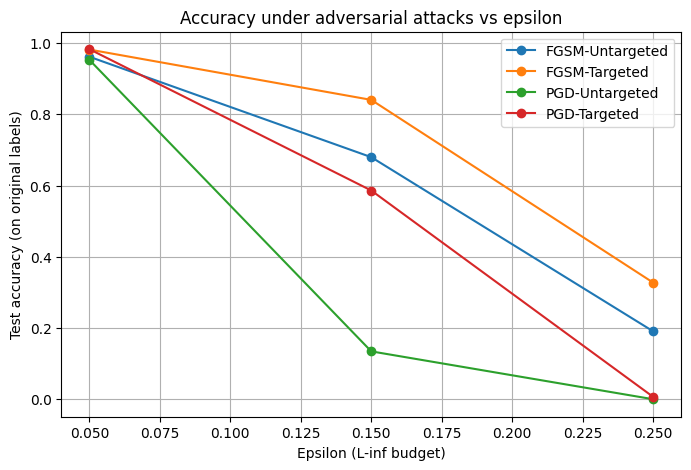

Saved plot: outputs/accuracy_vs_eps.png


In [11]:
# 10) Plot accuracy vs epsilon
plt.figure(figsize=(8,5))
for attack in attack_types:
    plt.plot(EPS_LIST, results_table[attack], marker='o', label=attack)
plt.xlabel("Epsilon (L-inf budget)")
plt.ylabel("Test accuracy (on original labels)")
plt.title("Accuracy under adversarial attacks vs epsilon")
plt.grid(True)
plt.legend()
plot_path = os.path.join(OUTPUT_DIR, "accuracy_vs_eps.png")
plt.savefig(plot_path, bbox_inches='tight')
plt.show()
print("Saved plot:", plot_path)


Single-sample analysis (index=123):
Original label: 6
Pred (clean): 6
Loss L(x, y_orig): 1.192093e-07

FGSM Untargeted: Pred after attack: 6
Loss L(x_adv, y_orig): 2.781251e-02

FGSM Targeted (target=7): Pred after attack: 6
Loss L(x_adv, y_orig): 3.269738e-02
Loss L(x_adv, y_target): 6.430364e+00

PGD Untargeted: Pred after attack: 5
Loss L(x_adv, y_orig): 5.706165e+00

PGD Targeted (target=7): Pred after attack: 7
Loss L(x_adv, y_orig): 5.249017e+00
Loss L(x_adv, y_target): 1.599798e-02


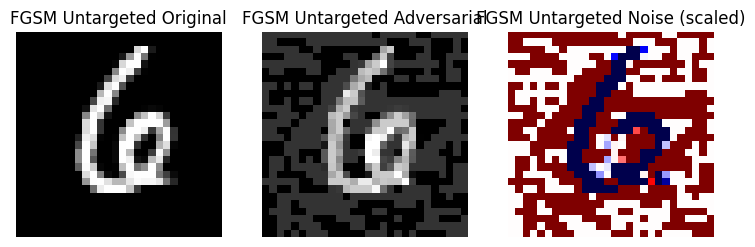

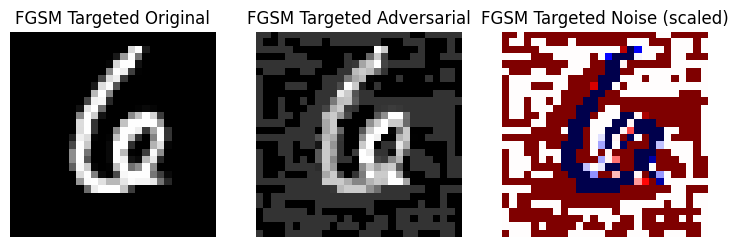

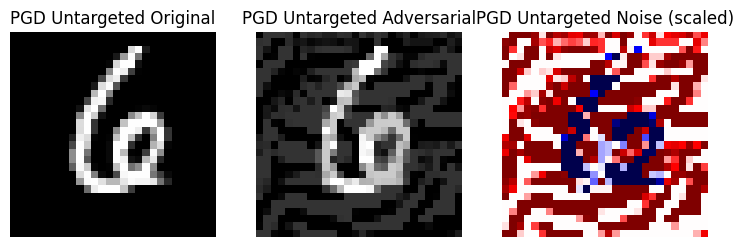

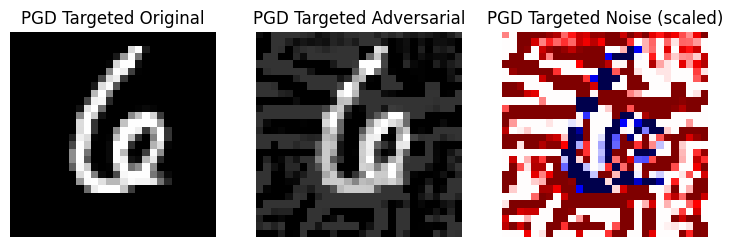

Saved visualizations to outputs/


In [12]:
# 11) Single-sample analysis (visualization + losses)
def single_sample_analysis(model, dataset, index=0, eps=0.2):
    model.eval()
    x, y = dataset[index]
    x = x.unsqueeze(0).to(DEVICE)
    y_tensor = torch.tensor([y], dtype=torch.long).to(DEVICE)
    target_label = torch.tensor([(y + 1) % 10], dtype=torch.long).to(DEVICE)

    # clean forward (no_grad is fine here)
    with torch.no_grad():
        out_clean = model(x)
        pred_clean = out_clean.argmax(dim=1).item()
    loss_x_y = criterion(out_clean, y_tensor).item()

    # FGSM untargeted
    x_fgsm_unt = fgsm_attack(model, x, y_tensor, eps, targeted=False)
    out_fgsm_unt = model(x_fgsm_unt)
    pred_fgsm_unt = out_fgsm_unt.argmax(dim=1).item()
    loss_xadv_y_fgsm_unt = criterion(out_fgsm_unt, y_tensor).item()

    # FGSM targeted
    x_fgsm_tar = fgsm_attack(model, x, y_tensor, eps, targeted=True, target_label=target_label)
    out_fgsm_tar = model(x_fgsm_tar)
    pred_fgsm_tar = out_fgsm_tar.argmax(dim=1).item()
    loss_xadv_y_fgsm_tar = criterion(out_fgsm_tar, y_tensor).item()
    loss_xadv_target_fgsm_tar = criterion(out_fgsm_tar, target_label).item()

    # PGD untargeted
    x_pgd_unt = pgd_attack(model, x, y_tensor, eps, alpha=PGD_ALPHA, iters=PGD_STEPS, targeted=False)
    out_pgd_unt = model(x_pgd_unt)
    pred_pgd_unt = out_pgd_unt.argmax(dim=1).item()
    loss_xadv_y_pgd_unt = criterion(out_pgd_unt, y_tensor).item()

    # PGD targeted
    x_pgd_tar = pgd_attack(model, x, y_tensor, eps, alpha=PGD_ALPHA, iters=PGD_STEPS, targeted=True, target_label=target_label)
    out_pgd_tar = model(x_pgd_tar)
    pred_pgd_tar = out_pgd_tar.argmax(dim=1).item()
    loss_xadv_y_pgd_tar = criterion(out_pgd_tar, y_tensor).item()
    loss_xadv_target_pgd_tar = criterion(out_pgd_tar, target_label).item()

    # return a dict
    return {
        "index": index,
        "orig_label": int(y),
        "pred_clean": int(pred_clean),
        "loss_x_y": loss_x_y,
        "fgsm_unt": {"xadv": x_fgsm_unt.detach().cpu(), "pred": pred_fgsm_unt, "loss_xadv_y": loss_xadv_y_fgsm_unt},
        "fgsm_tar": {"xadv": x_fgsm_tar.detach().cpu(), "pred": pred_fgsm_tar, "loss_xadv_y": loss_xadv_y_fgsm_tar, "loss_xadv_target": loss_xadv_target_fgsm_tar, "target_label": int(target_label.cpu())},
        "pgd_unt": {"xadv": x_pgd_unt.detach().cpu(), "pred": pred_pgd_unt, "loss_xadv_y": loss_xadv_y_pgd_unt},
        "pgd_tar": {"xadv": x_pgd_tar.detach().cpu(), "pred": pred_pgd_tar, "loss_xadv_y": loss_xadv_y_pgd_tar, "loss_xadv_target": loss_xadv_target_pgd_tar, "target_label": int(target_label.cpu())},
        "x": x.detach().cpu()
    }

def show_image_triplet(x_orig, x_adv, title_prefix="", savepath=None):
    x_orig_np = x_orig.squeeze().numpy()
    x_adv_np = x_adv.squeeze().numpy()
    delta = x_adv_np - x_orig_np
    # scale delta for visibility
    dmin, dmax = delta.min(), delta.max()
    if abs(dmax - dmin) < 1e-12:
        delta_vis = np.zeros_like(delta)
    else:
        delta_vis = (delta - dmin) / (dmax - dmin)
    fig, axes = plt.subplots(1,3, figsize=(9,3))
    axes[0].imshow(x_orig_np, cmap='gray')
    axes[0].set_title(f"{title_prefix} Original")
    axes[0].axis('off')
    axes[1].imshow(x_adv_np, cmap='gray')
    axes[1].set_title(f"{title_prefix} Adversarial")
    axes[1].axis('off')
    axes[2].imshow(delta_vis, cmap='seismic')
    axes[2].set_title(f"{title_prefix} Noise (scaled)")
    axes[2].axis('off')
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

# choose a sample index and epsilon for single-sample visualization
SAMPLE_INDEX = 123
eps_for_sample = 0.2

single_res = single_sample_analysis(model, test_ds, index=SAMPLE_INDEX, eps=eps_for_sample)

# Print results with high precision (scientific notation for small losses)
print(f"\nSingle-sample analysis (index={SAMPLE_INDEX}):")
print("Original label:", single_res['orig_label'])
print("Pred (clean):", single_res['pred_clean'])
print(f"Loss L(x, y_orig): {single_res['loss_x_y']:.6e}")

print("\nFGSM Untargeted: Pred after attack:", single_res['fgsm_unt']['pred'])
print(f"Loss L(x_adv, y_orig): {single_res['fgsm_unt']['loss_xadv_y']:.6e}")

print("\nFGSM Targeted (target={}): Pred after attack: {}".format(single_res['fgsm_tar']['target_label'], single_res['fgsm_tar']['pred']))
print(f"Loss L(x_adv, y_orig): {single_res['fgsm_tar']['loss_xadv_y']:.6e}")
print(f"Loss L(x_adv, y_target): {single_res['fgsm_tar']['loss_xadv_target']:.6e}")

print("\nPGD Untargeted: Pred after attack:", single_res['pgd_unt']['pred'])
print(f"Loss L(x_adv, y_orig): {single_res['pgd_unt']['loss_xadv_y']:.6e}")

print("\nPGD Targeted (target={}): Pred after attack: {}".format(single_res['pgd_tar']['target_label'], single_res['pgd_tar']['pred']))
print(f"Loss L(x_adv, y_orig): {single_res['pgd_tar']['loss_xadv_y']:.6e}")
print(f"Loss L(x_adv, y_target): {single_res['pgd_tar']['loss_xadv_target']:.6e}")

# Visualize and save images
show_image_triplet(single_res["x"], single_res["fgsm_unt"]["xadv"], title_prefix="FGSM Untargeted", savepath=os.path.join(OUTPUT_DIR,"fgsm_unt_sample.png"))
show_image_triplet(single_res["x"], single_res["fgsm_tar"]["xadv"], title_prefix="FGSM Targeted", savepath=os.path.join(OUTPUT_DIR,"fgsm_tar_sample.png"))
show_image_triplet(single_res["x"], single_res["pgd_unt"]["xadv"], title_prefix="PGD Untargeted", savepath=os.path.join(OUTPUT_DIR,"pgd_unt_sample.png"))
show_image_triplet(single_res["x"], single_res["pgd_tar"]["xadv"], title_prefix="PGD Targeted", savepath=os.path.join(OUTPUT_DIR,"pgd_tar_sample.png"))

print("Saved visualizations to outputs/")


In [13]:
# 12) Explicit targeted-success rates (print)
for eps in EPS_LIST:
    _, success_fgsm = evaluate_attack_on_loader(model, test_loader, fgsm_batch, eps, targeted=True, target_fn=next_label_fn, verbose=False)
    _, success_pgd  = evaluate_attack_on_loader(model, test_loader, pgd_batch, eps, targeted=True, target_fn=next_label_fn, verbose=False)
    print(f"Eps={eps:.3f} | FGSM Target Success Rate: {success_fgsm:.4f} | PGD Target Success Rate: {success_pgd:.4f}")

print("\nAll done. CSV, plots, and sample images are in the 'outputs/' directory.")

Eps=0.050 | FGSM Target Success Rate: 0.0053 | PGD Target Success Rate: 0.0066
Eps=0.150 | FGSM Target Success Rate: 0.0828 | PGD Target Success Rate: 0.3892
Eps=0.250 | FGSM Target Success Rate: 0.3286 | PGD Target Success Rate: 0.9911

All done. CSV, plots, and sample images are in the 'outputs/' directory.
